# Question 3 — Backtesting Engine
Algorithmic Trading Winter Project — Finance And Analytics Club, IIT Kanpur

This notebook implements a **long-only backtesting engine** from scratch. It takes the dataset (with a `Signal` column) as input, starts with **1,000 INR** initial capital, and puts *all* capital into a single long trade whenever a Buy signal fires. Positions are closed on a **Stop Loss**, a **Take Profit**, or an opposite (Sell) signal — whichever comes first.

The entry signal used to drive trades here is the **RSI Signal** from Question 2 (a simple, well understood mean-reversion trigger: buy when RSI is oversold, exit on overbought/SL/TP). The engine itself is generic — swap `signal_col` to any of the other signal columns (Bollinger, MACD, SO, ADX, ATR) to drive the same engine with a different strategy.

## Setup: download data, rebuild indicators, and generate the RSI signal (from Q1 & Q2)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "TCS.NS"
data = yf.download(ticker, start='2023-01-01', end='2023-12-31')

# ---------------- Indicator functions (from Question 1) ----------------

def sma(dat, period: int):
    length = len(dat.index)
    smas = []
    for i in range(0, period - 1):
        smas.append(None)
    for i in range(period - 1, length):
        sumbox = []
        for j in range(0, period):
            a = float(dat.iloc[i - j]['Close'][ticker])
            sumbox.append(a)
        smas.append(sum(sumbox) / period)
    dat[str(period) + '-day SMA'] = smas
    return dat

def std_dev(dat, column: str, period: int):
    length = len(dat.index)
    std_devs = []
    for i in range(0, period - 1):
        std_devs.append(None)
    for i in range(period - 1, length):
        dataset1 = []
        for j in range(0, period):
            a = dat.iloc[i - j][column]
            if isinstance(a, pd.Series):
                a = a.iloc[0]
            dataset1.append(a)
        avg = sum(dataset1) / len(dataset1)
        sumbo = [(x - avg) ** 2 for x in dataset1]
        std_devs.append((sum(sumbo) / len(sumbo)) ** 0.5)
    dat['Std Dev of ' + column] = std_devs
    return dat

def stochast(dat, period: int):
    length = len(dat.index)
    stochasts = []
    for i in range(0, period - 1):
        stochasts.append(None)
    for i in range(period - 1, length):
        valueshigh, valueslow = [], []
        for j in range(0, period):
            valueshigh.append(float(dat.iloc[i - j]['High'][ticker]))
            valueslow.append(float(dat.iloc[i - j]['Low'][ticker]))
        highvalue, lowvalue = max(valueshigh), min(valueslow)
        currentvalue = float(dat.iloc[i]['Close'][ticker])
        stochasts.append(((currentvalue - lowvalue) / (highvalue - lowvalue)) * 100)
    dat[str(period) + '-day SO'] = stochasts
    return dat

def rsi(dat, period: int):
    length = len(dat.index)
    gainloss = [0]
    for i in range(1, length):
        a = float(dat.iloc[i - 1]['Close'][ticker])
        b = float(dat.iloc[i]['Close'][ticker])
        gainloss.append(b - a)
    gains, losses = [], []
    for i in gainloss:
        if i >= 0:
            gains.append(i); losses.append(0)
        else:
            gains.append(0); losses.append(abs(i))
    rsis = []
    for i in range(0, period - 1):
        rsis.append(None)
    for i in range(period - 1, length):
        vg = [gains[i - j] for j in range(period)]
        vl = [losses[i - j] for j in range(period)]
        avggain, avgloss = sum(vg) / period, sum(vl) / period
        if avgloss == 0:
            rsis.append(100)
            continue
        rs = avggain / avgloss
        rsis.append(100 - (100 / (1 + rs)))
    dat[str(period) + '-day RSI'] = rsis
    return dat

def ema(dat, period: int):
    length = len(dat.index)
    emas = []
    for i in range(0, period - 1):
        emas.append(None)
    sumbox = [float(dat.iloc[i]['Close'][ticker]) for i in range(period)]
    emas.append(sum(sumbox) / len(sumbox))
    multiplier = 2 / (period + 1)
    for i in range(period, length):
        a = float(dat.iloc[i]['Close'][ticker])
        b = emas[i - 1]
        emas.append(a * multiplier + b * (1 - multiplier))
    dat[str(period) + '-day EMA'] = emas
    return dat

def macd(dat1, fastperiod: int, slowperiod: int, signalsmoothper: int):
    dat1 = ema(dat1, fastperiod)
    dat1 = ema(dat1, slowperiod)
    macd_vals = np.array(dat1[str(fastperiod) + '-day EMA'], dtype=float) - \
                np.array(dat1[str(slowperiod) + '-day EMA'], dtype=float)
    dat1['MACD ({0},{1})'.format(fastperiod, slowperiod)] = macd_vals
    dat1[str(signalsmoothper) + '-day SMA of MACD'] = dat1['MACD ({0},{1})'.format(fastperiod, slowperiod)].rolling(signalsmoothper).mean()
    return dat1

def atr(dat, period: int):
    length = len(dat.index)
    h_l, h_cp, l_cp = [], [None], [None]
    x, y = float(dat.iloc[0]['High'][ticker]), float(dat.iloc[0]['Low'][ticker])
    h_l.append(x - y)
    for i in range(1, length):
        a = float(dat.iloc[i]['High'][ticker])
        b = float(dat.iloc[i]['Low'][ticker])
        c = float(dat.iloc[i - 1]['Close'][ticker])
        h_l.append(a - b); h_cp.append(abs(a - c)); l_cp.append(abs(b - c))
    trs = [h_l[0]]
    for i in range(1, length):
        trs.append(max(h_l[i], h_cp[i], l_cp[i]))
    atrs = []
    for i in range(0, period - 1):
        sumbox = trs[0:i]
        atrs.append(sum(sumbox) / (i + 1) if i > 0 else trs[0])
    for i in range(period - 1, length):
        m, n = atrs[i - 1], trs[i]
        atrs.append(((period - 1) * m + n) / period)
    dat[str(period) + '-day ATR'] = atrs
    return dat

def adm(dat1, period: int):
    length = len(dat1.index)
    dat1 = atr(dat1, period)
    h_ph, l_pl = [None], [None]
    for i in range(1, length):
        a = float(dat1.iloc[i]['High'][ticker])
        b = float(dat1.iloc[i - 1]['High'][ticker])
        c = float(dat1.iloc[i]['Low'][ticker])
        d = float(dat1.iloc[i - 1]['Low'][ticker])
        h_ph.append(a - b); l_pl.append(d - c)
    plusdm, minusdm = [None], [None]
    for i in range(1, length):
        if h_ph[i] > l_pl[i] and h_ph[i] > 0:
            plusdm.append(h_ph[i]); minusdm.append(0)
        elif l_pl[i] > h_ph[i] and l_pl[i] > 0:
            plusdm.append(0); minusdm.append(l_pl[i])
        else:
            plusdm.append(0); minusdm.append(0)
    dat1['+DM'], dat1['-DM'] = plusdm, minusdm
    dat1['Smooth+DM'] = dat1['+DM'].rolling(period).mean()
    dat1['Smooth-DM'] = dat1['-DM'].rolling(period).mean()
    dat1['+DI'] = (dat1['Smooth+DM'] / dat1[str(period) + '-day ATR']) * 100
    dat1['-DI'] = (dat1['Smooth-DM'] / dat1[str(period) + '-day ATR']) * 100
    dat1['DX'] = abs((dat1['+DI'] - dat1['-DI']) / (dat1['+DI'] + dat1['-DI'])) * 100
    dat1[str(period) + '-day ADX'] = dat1['DX'].rolling(period).mean()
    dat1 = dat1.drop(columns=['DX', '+DI', '-DI', 'Smooth+DM', 'Smooth-DM', '+DM', '-DM'])
    return dat1

# Compute every indicator once so all signal functions below have what they need
data = sma(data, 20)
data = std_dev(data, 'Close', 20)
data = stochast(data, 14)
data = rsi(data, 14)
data = macd(data, 12, 26, 9)
data = adm(data, 14)

data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,20-day SMA,Std Dev of Close,14-day SO,14-day RSI,12-day EMA,26-day EMA,"MACD (12,26)",9-day SMA of MACD,14-day ATR,14-day ADX
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2023-12-22,3513.734375,3533.903386,3456.764832,3491.681649,2413058,3346.213965,122.436688,75.363693,74.704637,3430.511459,3346.403018,84.108441,68.170633,68.574662,51.228690
2023-12-26,3487.592529,3522.922787,3482.630532,3509.920958,1285231,3361.763452,119.624217,66.955514,70.625933,3439.293162,3356.861500,82.431662,72.054800,66.554490,51.864570
2023-12-27,3501.972900,3508.404946,3462.278038,3490.762809,1293976,3377.432385,116.395848,67.814182,67.761575,3448.936199,3367.610493,81.325706,76.049442,65.095377,51.553959
2023-12-28,3491.589600,3526.598391,3484.422643,3513.734301,1682889,3390.579016,113.666385,64.726707,65.852602,3455.498260,3376.794130,78.704130,79.392842,63.458261,52.461162
2023-12-29,3485.617188,3512.448185,3459.889006,3484.330868,1574996,3404.628467,106.983115,62.950811,64.415429,3460.131941,3384.855097,75.276844,80.556991,62.679755,52.592705


In [2]:
def rsi_signal(dat, period: int = 14, oversold: float = 30, overbought: float = 70):
    r = dat[str(period) + '-day RSI']
    signal = []
    for v in r:
        if pd.isna(v):
            signal.append(0)
        elif v <= oversold:
            signal.append(1)
        elif v >= overbought:
            signal.append(-1)
        else:
            signal.append(0)
    dat['RSI Signal'] = signal
    return dat

data = rsi_signal(data, 14)
print("Buy signals:", (data['RSI Signal'] == 1).sum(), " Sell signals:", (data['RSI Signal'] == -1).sum())

Buy signals: 22  Sell signals: 40


## The Backtesting Engine

**Stop Loss = 2% (`stop_loss_pct = 0.02`)** and **Take Profit = 5% (`take_profit_pct = 0.05`)** — set as parameters/comments below, easy to tune.

Logic per day:
- If **not** in a position and the signal is Buy (`1`) -> enter a long trade, deploying **all** current capital at that day's close.
- If **in** a position -> exit (sell everything) the moment any of these trigger:
  - price has fallen **stop_loss_pct** below the entry price (Stop Loss), or
  - price has risen **take_profit_pct** above the entry price (Take Profit), or
  - the indicator gives a Sell signal (`-1`).
- Any position still open on the last day is force-closed at the final price so every trade is accounted for.

The engine tracks the **daily portfolio value** (cash when flat, mark-to-market position value when in a trade), the **return of every completed trade**, and win/loss counts, from which Net Profit, Sharpe Ratio and Max Drawdown are computed.

In [3]:
def backtest(dat, signal_col: str = 'RSI Signal', initial_capital: float = 1000,
             stop_loss_pct: float = 0.02, take_profit_pct: float = 0.05):
    """
    Long-only backtesting engine.
    Stop Loss   : 2%  (stop_loss_pct = 0.02)   -> exit a losing trade after a 2% adverse move
    Take Profit : 5%  (take_profit_pct = 0.05) -> exit a winning trade after a 5% favourable move
    All capital is deployed into a single position at a time (no partial sizing, no leverage).
    """
    price = dat['Close'][ticker]
    signals = dat[signal_col]
    length = len(dat)

    capital = initial_capital     # cash on hand when flat
    units = 0.0                   # shares held while in a trade
    in_position = False           # boolean flag: ongoing trade or not
    entry_price = 0.0

    portfolio_value = []          # daily mark-to-market portfolio value
    trade_returns = []            # % return of each completed trade
    winning_trades = 0
    losing_trades = 0
    total_trades = 0

    for i in range(length):
        p = price.iloc[i]
        sig = signals.iloc[i]

        if not in_position:
            if sig == 1:
                # ---- enter long trade with all available capital ----
                units = capital / p
                entry_price = p
                in_position = True
                portfolio_value.append(units * p)
            else:
                portfolio_value.append(capital)
        else:
            change_pct = (p - entry_price) / entry_price
            exit_trade = False
            if change_pct <= -stop_loss_pct:
                exit_trade = True          # stop loss hit
            elif change_pct >= take_profit_pct:
                exit_trade = True          # take profit hit
            elif sig == -1:
                exit_trade = True          # indicator sell signal

            if exit_trade:
                capital = units * p
                trade_return = (capital - (units * entry_price)) / (units * entry_price)
                trade_returns.append(trade_return)
                total_trades += 1
                if trade_return > 0:
                    winning_trades += 1
                else:
                    losing_trades += 1
                units = 0.0
                in_position = False
                portfolio_value.append(capital)
            else:
                portfolio_value.append(units * p)   # still in the trade, mark-to-market

    # force-close any trade still open on the last day
    if in_position:
        capital = units * price.iloc[-1]
        trade_return = (capital - (units * entry_price)) / (units * entry_price)
        trade_returns.append(trade_return)
        total_trades += 1
        if trade_return > 0:
            winning_trades += 1
        else:
            losing_trades += 1
        portfolio_value[-1] = capital

    dat['Portfolio Value'] = portfolio_value

    # ---- performance metrics ----
    portfolio_series = pd.Series(portfolio_value, index=dat.index)
    daily_returns = portfolio_series.pct_change().dropna()

    net_profit = capital - initial_capital
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 else 0.0

    running_max = portfolio_series.cummax()
    drawdown = (portfolio_series - running_max) / running_max
    max_drawdown = drawdown.min()

    print("----------- Backtest Results -----------")
    print(f"Net Profit            : {net_profit:.2f} INR")
    print(f"Sharpe Ratio           : {sharpe_ratio:.4f}")
    print(f"Maximum Drawdown        : {max_drawdown * 100:.2f}%")
    print(f"Total Trades            : {total_trades}")
    print(f"Winning Trades          : {winning_trades}")
    print(f"Losing Trades           : {losing_trades}")
    print(f"Winning + Losing == Total? {winning_trades + losing_trades == total_trades}")

    return dat, {
        'net_profit': net_profit,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'total_trades': total_trades,
        'winning_trades': winning_trades,
        'losing_trades': losing_trades,
        'trade_returns': trade_returns,
    }

data, results = backtest(data, signal_col='RSI Signal', initial_capital=1000,
                          stop_loss_pct=0.02, take_profit_pct=0.05)

----------- Backtest Results -----------
Net Profit            : 72.80 INR
Sharpe Ratio           : 0.8798
Maximum Drawdown        : -8.74%
Total Trades            : 5
Winning Trades          : 3
Losing Trades           : 2
Winning + Losing == Total? True


## Equity Curve

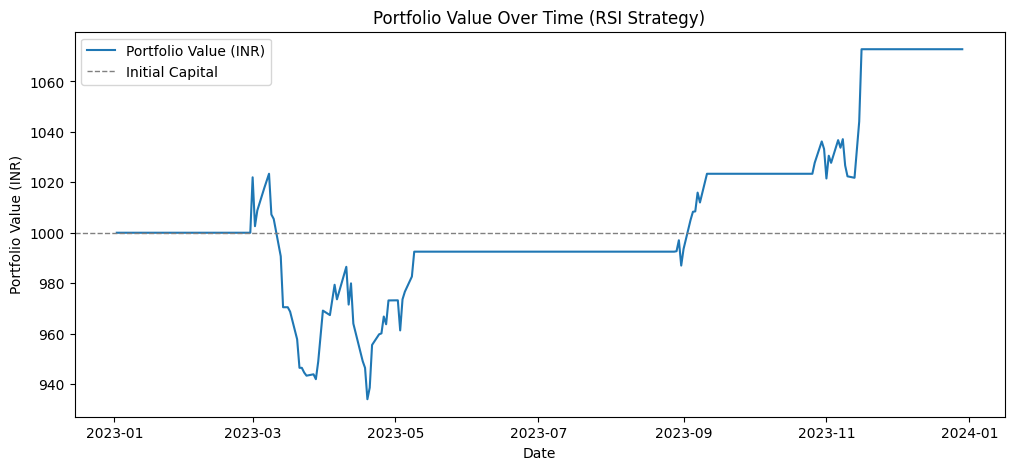

In [4]:
plt.figure(figsize=(12, 5))
plt.title('Portfolio Value Over Time (RSI Strategy)')
plt.plot(data.index, data['Portfolio Value'], label='Portfolio Value (INR)')
plt.axhline(1000, color='gray', linestyle='--', linewidth=1, label='Initial Capital')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (INR)')
plt.legend()
plt.show()

## Trying a Different Signal
Since the engine is generic, the same function can be re-run with any other signal column computed in Question 2 — for example the Bollinger Bands signal — just by regenerating that column and passing it in.

In [5]:
def bollinger_signal(dat, period: int = 20):
    upper = dat[str(period) + '-day SMA'] + 2 * dat['Std Dev of Close']
    lower = dat[str(period) + '-day SMA'] - 2 * dat['Std Dev of Close']
    price = dat['Close'][ticker]
    signal = []
    for p, u, l in zip(price, upper, lower):
        if pd.isna(u) or pd.isna(l):
            signal.append(0)
        elif p <= l:
            signal.append(1)
        elif p >= u:
            signal.append(-1)
        else:
            signal.append(0)
    dat['Bollinger Signal'] = signal
    return dat

data = bollinger_signal(data, 20)
data, results_bb = backtest(data, signal_col='Bollinger Signal', initial_capital=1000,
                             stop_loss_pct=0.02, take_profit_pct=0.05)

----------- Backtest Results -----------
Net Profit            : -21.10 INR
Sharpe Ratio           : -0.3169
Maximum Drawdown        : -5.17%
Total Trades            : 3
Winning Trades          : 1
Losing Trades           : 2
Winning + Losing == Total? True
